# r/urbancarliving

#### Reddit group description:
For whatever reason, you are now living out of a vehicle part time or full time. This is a place to share the experience and tips with others in a similar situation.

Created Oct 24, 2012

Public
108K members

Top 2%
Rank by size 

### Topic Modeling

In [31]:
import pandas as pd
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [32]:
# Load and examine data
df = pd.read_csv('Data/reddit/urbancarliving.csv')
print(f"Loaded {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"First few comments:")
for i in range(3):
    print(f"{i+1}: {df.iloc[i, 0][:100]}...")

Loaded 6951 comments
Columns: ['0']
First few comments:
1: Getting mail...
2: Some homeless shelters will accept mail or allow you to use their address. I have one as my drivers ...
3: I Was able to get a PO Box no issue, so IDK why you're unable to...


In [40]:
# Clean and prepare text
def clean_text(text):
    if not isinstance(text, str) or text in ['[deleted]', '[removed]', '']:
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation, numbers, etc.
    text = re.sub(r"[^A-Za-z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# Apply cleaning
comments = df.iloc[:, 0].apply(clean_text)
comments = comments[comments.str.len() > 10]  # Remove very short comments
print(f"After cleaning: {len(comments)} comments")

# Tokenize and remove stopwords
swords = stopwords.words('english')

# Remove punctuation from stopwords to match your cleaned text
swords_clean = []
for word in swords:
    # Apply same cleaning as clean_text function
    clean_word = re.sub(r"[^A-Za-z\s]", "", word)
    if clean_word and len(clean_word) > 0:
        swords_clean.append(clean_word.lower())

# Remove duplicates and empty strings
swords_clean = list(set([word for word in swords_clean if word]))
swords_clean = sorted(swords_clean)

print(f"Original stopwords: {len(swords)}")
# print(swords)
print(f"Cleaned stopwords: {len(swords_clean)}")
# print(swords_clean)

# Add specific stopwords
reddit_stopwords = ['reddit', 'edit', 'update', 'deleted', 'removed', 'comment', 'post', 'thread']
additional_stopwords = ['lets', 'thats', 'people', 'even', 'time', 'way', 'thats', 'youre', 'much', 
                        'would', 'could', 'get', 'one', 'also', 'really', 'think', 'know', 'like']

swords_clean.extend(reddit_stopwords + additional_stopwords)

print(f"Extended stopwords: {len(swords_clean)}")
# print(swords_clean)

# Tokenize
wordlists = []
for comment in comments:
    words = [word for word in word_tokenize(comment.lower()) 
            if word not in swords_clean 
            and len(word) > 0
            and word.isalpha()]
    
    wordlists.append(words)

print(f"Prepared {len(wordlists)} comments for modeling")
pd.to_pickle(wordlists, "data/reddit/wordlists-urbancarliving.pkl")
pd.to_pickle(comments, "data/reddit/comments-urbancarliving.pkl")

After cleaning: 6572 comments
Original stopwords: 198
Cleaned stopwords: 196
Extended stopwords: 222
Prepared 6572 comments for modeling


In [34]:
# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
car: 1976
good: 818
go: 779
work: 726
use: 714
make: 642
need: 618
keep: 594
living: 591
lot: 542
got: 527
want: 517
back: 513
life: 507
day: 506
sleep: 494
live: 477
going: 468
money: 462
parking: 456


In [35]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)

# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")

# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

Topics found:

Topic 1:
car, good, go, want, keep, work, need, living, make, money

Topic 2:
car, go, good, work, use, day, living, need, keep, got

Topic 3:
car, use, good, need, work, make, go, keep, back, living

Topic 4:
car, use, work, good, make, parking, go, lot, sleep, living


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.004441  0.000662       1        1  29.935478
0     -0.003683 -0.000226       2        1  27.115686
1      0.000185 -0.003709       3        1  21.918964
2     -0.000943  0.003272       4        1  21.029872, topic_info=         Term         Freq        Total Category  logprob  loglift
20        car  1781.000000  1781.000000  Default  30.0000  30.0000
221        go   700.000000   700.000000  Default  29.0000  29.0000
338   parking   420.000000   420.000000  Default  28.0000  28.0000
1116    looks   158.000000   158.000000  Default  27.0000  27.0000
9         use   644.000000   644.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
330      park    80.296098   400.316875   Topic4  -5.8735  -0.0473
42        lot    90.484869   495.118520   Topic4  -5.7541  -0.1404
434      life    81.060526   462.052175   Topic4  -5.8641  -0.1813
812       day    79.631191   457.845311   Topic4  -5.8818  -0.1899
77      sleep    75.204401   452.574164   Topic4  -5.9390  -0.2355

[356 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
3         1  0.346193  address
3         2  0.187521  address
3         3  0.317343  address
3         4  0.144247  address
5254      1  0.453138     adhd
...     ...       ...      ...
4321      4  0.141322       yr
6700      1  0.158425      yrs
6700      2  0.475274      yrs
6700      3  0.158425      yrs
6700      4  0.158425      yrs

[980 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 3])

### Sentiment Analysis

In [36]:
# Sentiment Analysis for Reddit Comments
from textblob import TextBlob
import pandas as pd

# Apply sentiment analysis to your cleaned comments
print("Analyzing sentiment...")
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]

# Create dataframe with comments and polarity scores
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

print(f"Analyzed {len(df_sentiment)} comments")
print(f"Sentiment analysis complete!")

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(3, 'polarity')[['comment', 'polarity']])

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(3, 'polarity')[['comment', 'polarity']])

Analyzing sentiment...
Analyzed 6572 comments
Sentiment analysis complete!

Sentiment Statistics:
Mean polarity: 0.112
Median polarity: 0.059
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Neutral     2980
Positive    2866
Negative     726
Name: count, dtype: int64

Most Positive Comments:
                                  comment  polarity
130                    Best power station       1.0
176  Ya Washington state is your best bet       1.0
196                       Looks delicious       1.0

Most Negative Comments:
                                                comment  polarity
1115     Thats pathetic They couldnt have TALKED to you      -1.0
1247  Sounds like an absolutely terrible idea Just h...      -1.0
1633  Omgosh thats insane Id def be insurance shoppi...      -1.0


parking: 337 comments found
sleep: 597 comments found
bathroom: 97 comments found
water: 249 comments found
cook: 171 comments found
police: 91 comments found
noise: 25 comments found
solar: 94 comments found
work: 821 comments found


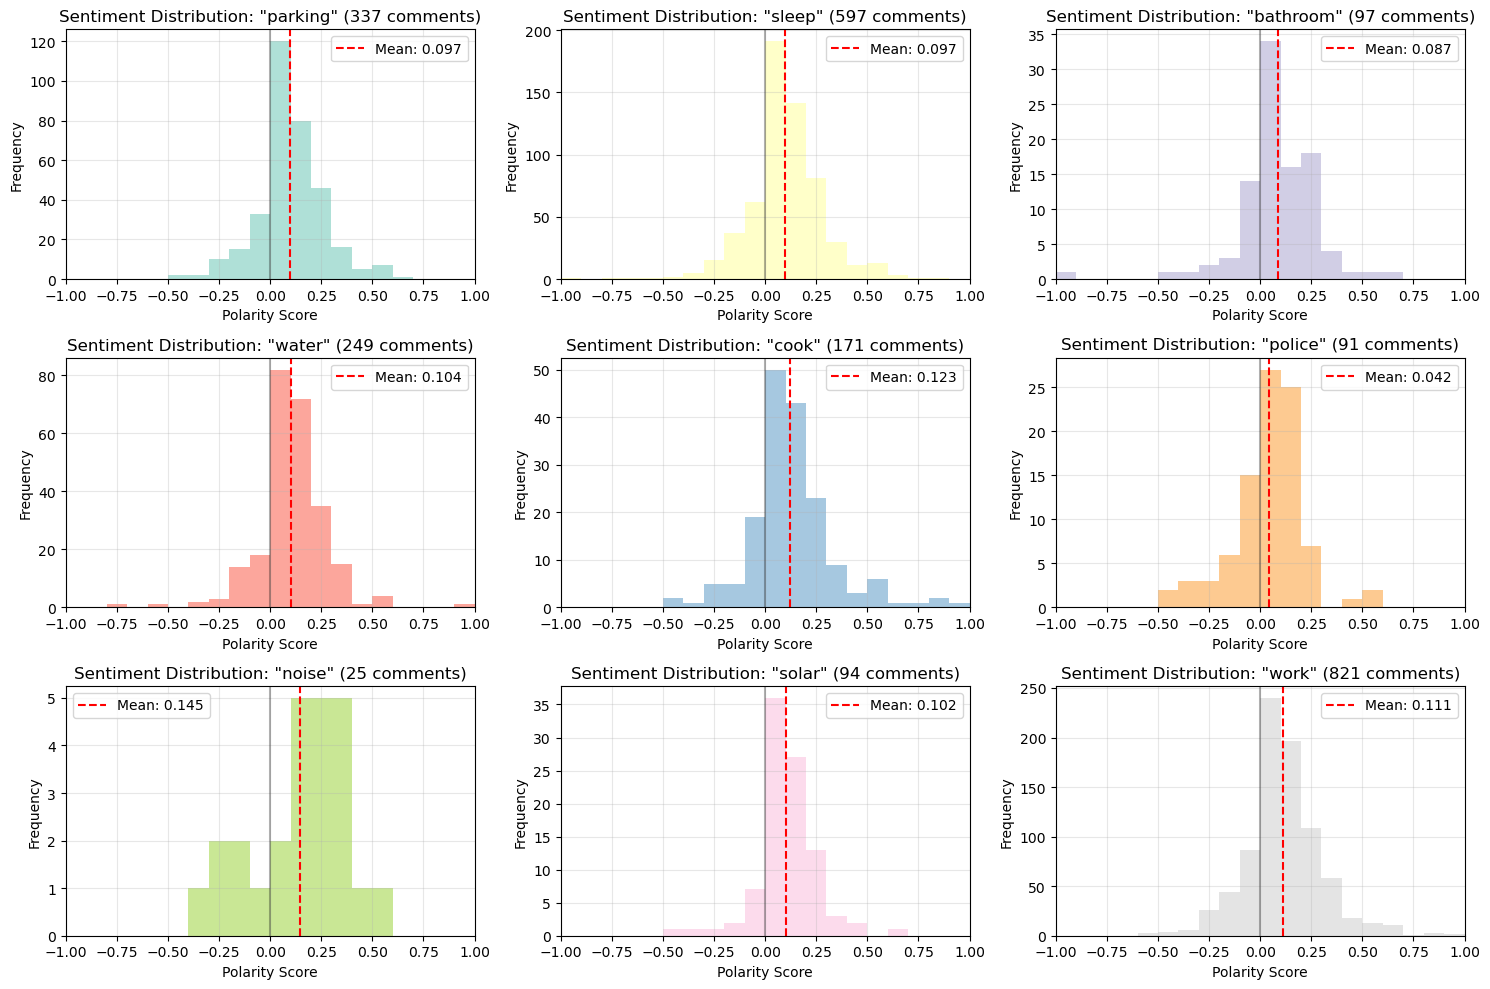

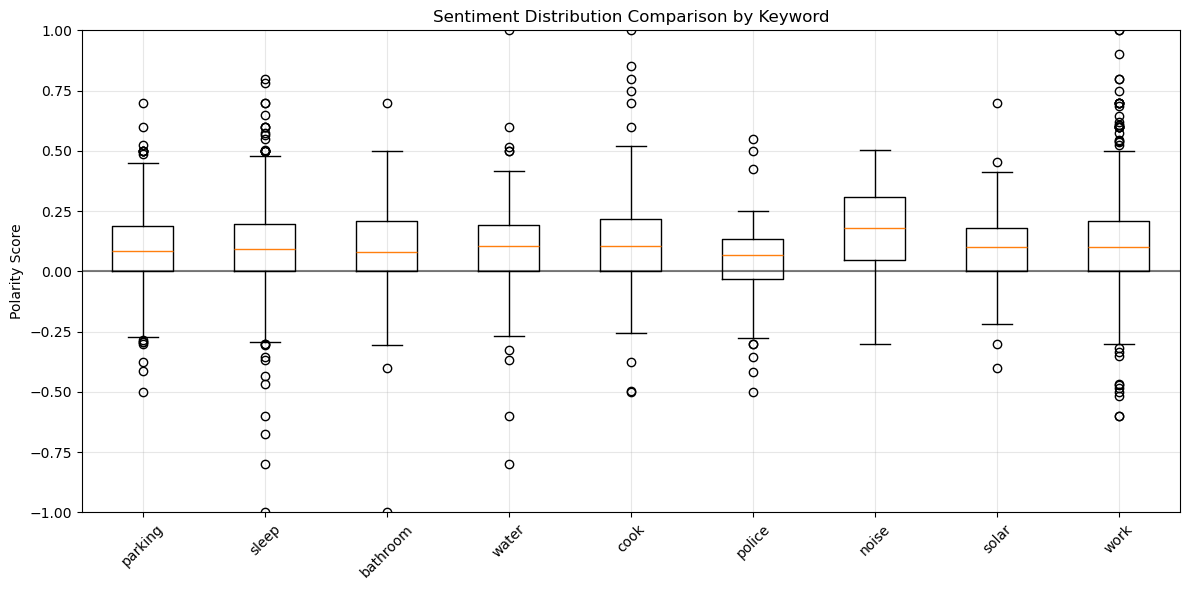

In [37]:
import matplotlib.pyplot as plt
import numpy as np


# Define keywords to analyze
keywords = ['parking', 'sleep', 'bathroom', 'water', 'cook', 'police', 'noise', 'solar', 'work']

# Function to find comments containing specific keywords
def get_sentiment_by_keyword(df_sentiment, keyword):
    mask = df_sentiment['comment'].str.contains(keyword, case=False, na=False)
    return df_sentiment[mask]['polarity']

# Collect sentiment data for each keyword
keyword_sentiments = {}
for keyword in keywords:
    sentiments = get_sentiment_by_keyword(df_sentiment, keyword)
    keyword_sentiments[keyword] = sentiments
    print(f"{keyword}: {len(sentiments)} comments found")

# Create subplot for each keyword
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
x_min, x_max = -1.0, 1.0  
bins = np.linspace(x_min, x_max, 21)  

for i, keyword in enumerate(keywords):
    sentiments = keyword_sentiments[keyword]
    
    if len(sentiments) > 0:
        # Create histogram with consistent bins and x-axis
        axes[i].hist(sentiments, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
        axes[i].axvline(sentiments.mean(), color='red', linestyle='--', 
                       label=f'Mean: {sentiments.mean():.3f}')
        axes[i].set_title(f'Sentiment Distribution: "{keyword}" ({len(sentiments)} comments)')
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xlim(x_min, x_max)  # Consistent x-axis range
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at 0 for reference
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No comments found\nfor "{keyword}"', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Sentiment Distribution: "{keyword}"')
        axes[i].set_xlim(x_min, x_max)  # Keep same x-axis even for empty plots
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plot comparison with consistent y-axis
plt.figure(figsize=(12, 6))
sentiment_data = [keyword_sentiments[keyword] for keyword in keywords if len(keyword_sentiments[keyword]) > 0]
labels = [keyword for keyword in keywords if len(keyword_sentiments[keyword]) > 0]

if sentiment_data:
    plt.boxplot(sentiment_data, labels=labels)
    plt.title('Sentiment Distribution Comparison by Keyword')
    plt.ylabel('Polarity Score')
    plt.ylim(x_min, x_max)  
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data found for any keywords")